# 03 — Inventory Optimization

Turns each model's forecast (and its *error*, not just the point
estimate) into a safety stock and reorder point, then simulates a simple
daily-review replenishment policy against what actually happened during
the four backtest windows from `02_forecasting_models.ipynb`.

**Method:**
- Safety stock = z x sigma_daily x sqrt(lead time) -- the standard
  newsvendor formula, using each model's own out-of-sample forecast
  error as sigma. Lead time = 7 days, target service level = 95%
  (z = 1.645).
- Reorder point = expected demand over the lead time (from that model's
  forecast) + safety stock.
- Policy: each day, receive due orders, fill actual demand from
  on-hand stock (recording any shortfall as a stockout), and reorder
  up to the reorder point whenever inventory position falls to or
  below it.

**On cost:** the Favorita dataset has no price data, so the dollar
figures below use illustrative unit economics (holding cost
$0.05/unit/day, stockout cost $2.00/unit) rather than real ones --
stated here so the numbers are read as *what the method produces*, not
as real business figures. Swap in real unit costs and the same code
produces real numbers.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.inventory import run_inventory_simulation, compute_daily_error_std

sns.set_theme(style="whitegrid")

detailed = pd.read_csv("../reports/backtest_detailed.csv", parse_dates=["date"])
print(detailed.shape)
detailed.head()

(2688, 7)


,fold,family,model,date,day_offset,actual,predicted
0,0,BEVERAGES,Seasonal naive,2017-04-26,1,58350.0,59979.0
1,0,BEVERAGES,Seasonal naive,2017-04-27,2,47617.0,49677.0
2,0,BEVERAGES,Seasonal naive,2017-04-28,3,68118.0,66068.0
3,0,BEVERAGES,Seasonal naive,2017-04-29,4,98609.0,96655.0
4,0,BEVERAGES,Seasonal naive,2017-04-30,5,101151.0,126860.0


## Forecast error -> safety stock, by family and model

In [2]:
errors = compute_daily_error_std(detailed)
errors.pivot(index="family", columns="model", values="sigma_daily").round(0)

model,Prophet,Seasonal naive,XGBoost
family,,,
BEVERAGES,13587.0,13578.0,11298.0
BREAD/BAKERY,1225.0,1483.0,1905.0
CLEANING,3520.0,4358.0,3756.0
DAIRY,2724.0,3214.0,3039.0
GROCERY I,13411.0,15156.0,13928.0
MEATS,1725.0,1339.0,2420.0
POULTRY,1664.0,2040.0,2756.0
PRODUCE,12981.0,8137.0,8192.0


Higher day-to-day forecast error (sigma) means more safety stock is
needed to hit the same 95% service level -- a noisier forecast costs
real inventory dollars even before anything goes wrong operationally.

## Run the simulation

In [3]:
sim = run_inventory_simulation(detailed, lead_time=7, service_level=0.95)
sim.to_csv("../reports/inventory_simulation.csv", index=False)
sim.round(1)

,family,model,safety_stock,reorder_point,avg_on_hand,total_demand,stockout_units,fill_rate,holding_cost,stockout_cost,total_cost
0,BEVERAGES,Prophet,59129.4,564109.6,66420.0,8253815.0,108506.7,1.0,371952.2,217013.4,588965.6
1,BEVERAGES,Seasonal naive,59090.6,576239.1,77033.3,8253815.0,84247.8,1.0,431386.5,168495.6,599882.1
2,BEVERAGES,XGBoost,49167.7,554822.1,58795.4,8253815.0,135113.6,1.0,329254.5,270227.2,599481.7
3,BREAD/BAKERY,Prophet,5331.2,88940.7,12218.4,1259864.7,2523.9,1.0,68422.9,5047.8,73470.7
4,BREAD/BAKERY,Seasonal naive,6452.0,85102.6,8711.8,1259864.7,7828.3,1.0,48786.0,15656.7,64442.7
5,BREAD/BAKERY,XGBoost,8292.4,99917.7,23037.7,1259864.7,0.0,1.0,129010.8,0.0,129010.8
6,CLEANING,Prophet,15320.3,166994.9,20247.4,2451080.0,50413.3,1.0,113385.7,100826.6,214212.3
7,CLEANING,Seasonal naive,18966.2,166330.2,19748.9,2451080.0,53072.1,1.0,110594.0,106144.1,216738.1
8,CLEANING,XGBoost,16347.0,171401.1,23552.1,2451080.0,32788.6,1.0,131891.6,65577.3,197468.9
9,DAIRY,Prophet,11853.6,154187.9,18215.5,2255022.0,28230.2,1.0,102007.0,56460.4,158467.5


## Total cost by model, across all 8 families

In [4]:
totals = sim.groupby("model")[["stockout_units", "holding_cost", "stockout_cost", "total_cost"]].sum()
totals = totals.sort_values("total_cost")
totals.round(0)

,stockout_units,holding_cost,stockout_cost,total_cost
model,,,,
Prophet,398385.0,1459346.0,796770.0,2256116.0
Seasonal naive,405418.0,1451521.0,810837.0,2262358.0
XGBoost,473082.0,1783713.0,946164.0,2729878.0


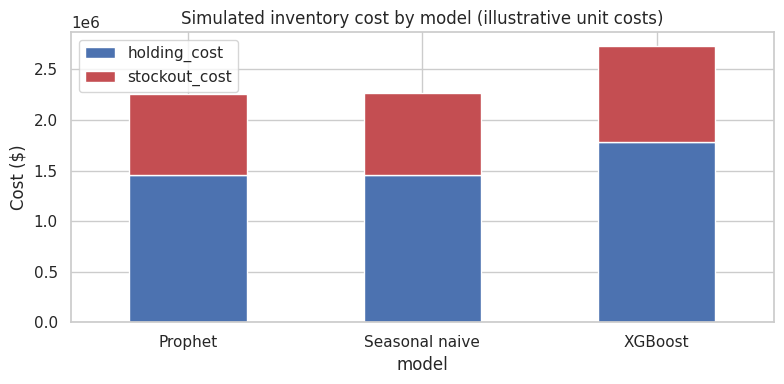

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
totals[["holding_cost", "stockout_cost"]].plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Simulated inventory cost by model (illustrative unit costs)")
ax.set_ylabel("Cost ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
best, worst = totals.index[0], totals.index[-1]
pct = (totals.loc[worst, "total_cost"] - totals.loc[best, "total_cost"]) / totals.loc[worst, "total_cost"] * 100
print(f"{best} vs {worst}: {pct:.1f}% lower simulated total inventory cost")
print(f"{best}: ${totals.loc[best, 'total_cost']:,.0f}   {worst}: ${totals.loc[worst, 'total_cost']:,.0f}")

Prophet vs XGBoost: 17.4% lower simulated total inventory cost
Prophet: $2,256,116   XGBoost: $2,729,878


**Consistent with the forecasting results in notebook 02**: Prophet and
the seasonal-naive baseline land close together and lowest-cost;
XGBoost's recursive forecast error compounds over the horizon, produces
a less reliable reorder point, and comes out highest-cost -- worse
forecasts translate directly into worse inventory outcomes, which is
the whole reason forecast accuracy is worth optimizing in the first
place, not just an academic metric.

## Service-level check: did the policy actually hit ~95% fill rate?

In [7]:
fill = sim.groupby("model").apply(
    lambda g: 1 - g["stockout_units"].sum() / g["total_demand"].sum()
).rename("overall_fill_rate")
(fill * 100).round(1)

/sessions/rcw-01d4jh3svensbps9eprtf15o/tmp/ipykernel_10/2258551699.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fill = sim.groupby("model").apply(


model
Prophet           98.8
Seasonal naive    98.8
XGBoost           98.6
Name: overall_fill_rate, dtype: float64

## Limitations (stated, not hidden)

- Safety stock assumes day-to-day forecast errors are independent
  (sigma scales with sqrt(lead time)); real demand errors are often
  autocorrelated, which would push the true safety stock requirement
  higher than shown here.
- Sigma is estimated from 4 backtest folds x 28 days = 112 observations
  per family/model -- enough to be directionally reliable, not enough
  for a production-grade estimate.
- Dollar figures use illustrative unit costs (documented above), not
  real product economics.

None of these change the conclusion (Prophet/baseline > XGBoost here),
but they're the honest boundaries of what this specific simulation
proves.

## Summary

This project scoped a 125M-row raw dataset down to a dense, reviewable
panel; built and fairly backtested three forecasting approaches; found
(and explained *why*) the simplest model was actually the strongest
here; and carried that forecast quality through to a concrete inventory
outcome -- the same end-to-end path described in the
AI-Powered Predictive Supply Chain Resilience Framework this project is
a proof-of-concept for.